# Ex.No.4 - Naive Bayes Classifier

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 10/02/2026_

## Naive Bayes Classifier

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [17]:
# load dataset
path = r"D:\VI\FOML\Datasets\diabetes.csv"
data = pd.read_csv(path)

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
# dataset info
print(data.shape)
print(data.columns)

data.describe()

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [19]:
# features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training dataset: ", X_train.shape)
print("Testing dataset: ", X_test.shape)

Training dataset:  (614, 8)
Testing dataset:  (154, 8)


In [20]:
# train model
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [21]:
# prediction
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 0 0 0 1 1 0 1 0 1]


In [22]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7662337662337663


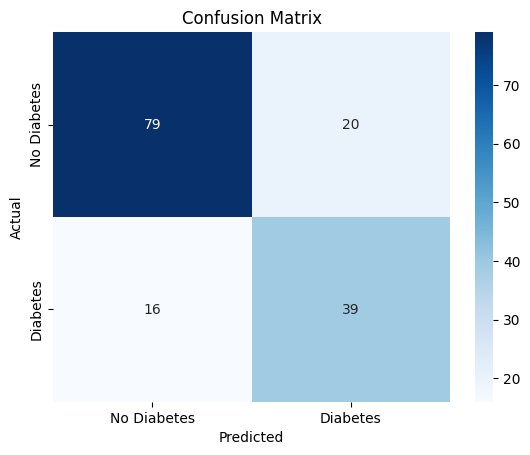

In [23]:
# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes","Diabetes"],
            yticklabels=["No Diabetes","Diabetes"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
# custom sample input
preg = 2
glu = 120
bp = 70
skin = 20
ins = 79
bmi = 25.0
dpf = 0.5
age = 33

custom_input = [[preg, glu, bp, skin, ins, bmi, dpf, age]]

# result
prediction = model.predict(custom_input)

if prediction[0] == 1:
    print("Person has Diabetes")
else:
    print("Person does not have Diabetes")

Person does not have Diabetes


C:\Users\Monish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
